# Análise — oracle_2.csv

Avalia os modelos **EfficientNet-B0, B3, B7** e as três estratégias de ensemble
(`ensemble_mean`, `ensemble_max`, `ensemble_vote`) sobre o conjunto de teste.

**Seções:**
1. Carregamento e preparação
2. Acurácia e métricas gerais por modelo / ensemble
3. Matrizes de confusão
4. Acurácia por classe ISUP
5. Distribuição de erros absolutos
6. Análise das estratégias de ensemble
7. Consenso e divergência entre modelos base
8. Erros graves (|pred − true| ≥ 3)
9. Erros adjacentes (|pred − true| = 1)
10. Oracle upper-bound
11. Casos mais difíceis
12. Sumário final

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score, mean_absolute_error
)
import warnings
warnings.filterwarnings('ignore')

CSV_PATH   = Path('oracle_2.csv')
TILES_DIR  = Path('/home/woshington/Projects/Doutorado/tiles')

MODELS     = ['b0', 'b3', 'b7']
ENSEMBLES  = ['ensemble_mean', 'ensemble_max', 'ensemble_vote']
ALL_PREDS  = MODELS + ENSEMBLES
ISUP_NAMES = [f'ISUP {i}' for i in range(6)]

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

---
## 1 · Carregamento e preparação

In [2]:
df = pd.read_csv(CSV_PATH)
print(f'Instâncias: {len(df)}   Colunas: {list(df.columns)}')
df.head()

Instâncias: 1590   Colunas: ['Unnamed: 0', 'img_id', 'true_label', 'b0', 'b3', 'b7', 'ensemble_mean', 'ensemble_max', 'ensemble_vote']


,Unnamed: 0,img_id,true_label,b0,b3,b7,ensemble_mean,ensemble_max,ensemble_vote
0,0,5ad2c7349c24ed5c4901522bec9d3077,0,0,0,0,0,0,0
1,1,96bb7ad81bef9aa7ce0280d7b49b6476,4,4,3,4,4,4,4
2,2,cb9bc923249b183c8fc5b904f622695e,2,2,3,3,3,3,3
3,3,f7af5eef3236461e745cd8b81f1cf93b,1,1,1,1,1,1,1
4,4,f35124ad7e0c9d8537a8e57966c06445,0,0,0,0,0,0,0


In [3]:
y = df['true_label']

# Erro absoluto e acerto por coluna
for col in ALL_PREDS:
    df[f'err_{col}']     = (df[col] - y).abs()
    df[f'correct_{col}'] = df[col] == y

# Estatísticas sobre os modelos base
df['n_correct']   = df[[f'correct_{m}' for m in MODELS]].sum(axis=1)
df['all_correct'] = df['n_correct'] == 3
df['all_wrong']   = df['n_correct'] == 0
df['oracle_ok']   = df['n_correct'] >= 1
df['pred_unique'] = df[MODELS].nunique(axis=1)
df['pred_std']    = df[MODELS].std(axis=1)
df['max_err']     = df[[f'err_{m}' for m in MODELS]].max(axis=1)
df['max_gap']     = df[MODELS].max(axis=1) - df[MODELS].min(axis=1)

print('Distribuição de n_correct (modelos base):')
print(df['n_correct'].value_counts().sort_index())
print()
print('Distribuição de true_label:')
print(y.value_counts().sort_index().rename(index=lambda x: f'ISUP {x}'))

Distribuição de n_correct (modelos base):
n_correct
0    271
1    241
2    418
3    660
Name: count, dtype: int64

Distribuição de true_label:
true_label
ISUP 0    434
ISUP 1    400
ISUP 2    200
ISUP 3    185
ISUP 4    187
ISUP 5    184
Name: count, dtype: int64


---
## 2 · Acurácia e métricas gerais

In [4]:
rows = []
for col in ALL_PREDS:
    acc   = accuracy_score(y, df[col])
    mae   = mean_absolute_error(y, df[col])
    kappa = cohen_kappa_score(y, df[col], weights='quadratic')
    rows.append({'Model': col, 'Accuracy': acc, 'MAE': mae, 'QWK': kappa})

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df['Accuracy'] = metrics_df['Accuracy'] * 100
metrics_df.style.format({'Accuracy': '{:.2f}%', 'MAE': '{:.4f}', 'QWK': '{:.4f}'}) \
               .background_gradient(cmap='RdYlGn', subset=['Accuracy', 'QWK']) \
               .background_gradient(cmap='RdYlGn_r', subset=['MAE'])

,Accuracy,MAE,QWK
Model,,,
b0,65.97%,0.4654,0.8484
b3,66.04%,0.4522,0.8570
b7,60.25%,0.5195,0.8440
ensemble_mean,69.81%,0.3962,0.8800
ensemble_max,58.30%,0.5522,0.8396
ensemble_vote,69.25%,0.4226,0.8598


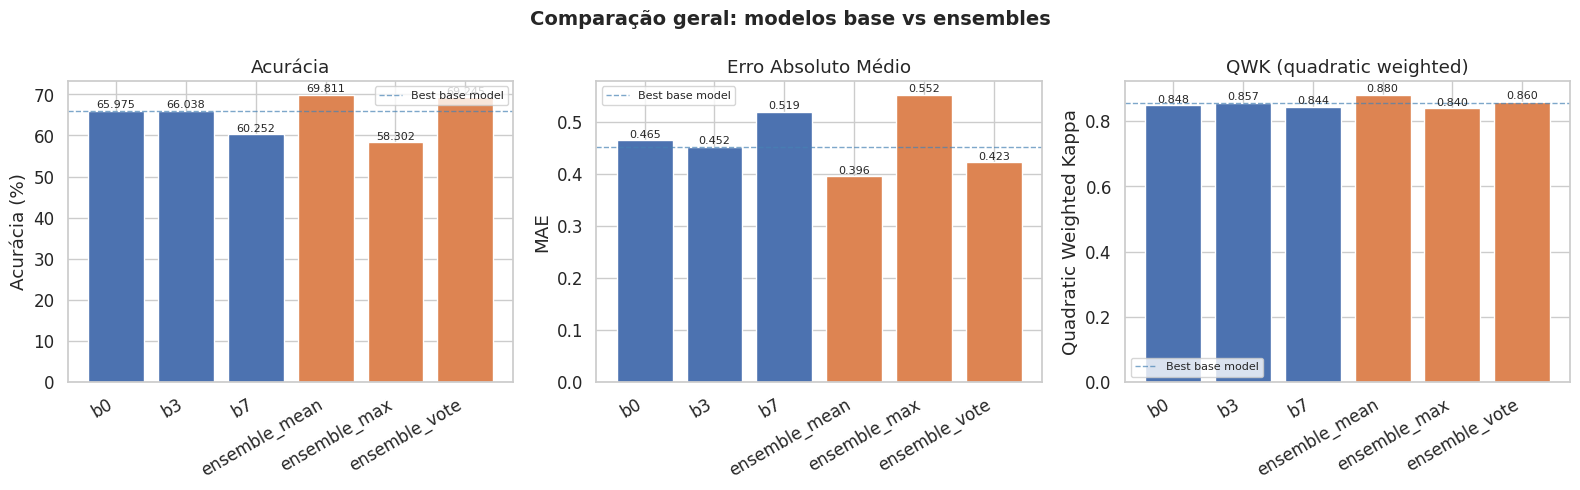

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = ['#4C72B0'] * 3 + ['#DD8452'] * 3  # blue=modelos, orange=ensembles

for ax, metric, ylabel, title in zip(
    axes,
    ['Accuracy', 'MAE', 'QWK'],
    ['Acurácia (%)', 'MAE', 'Quadratic Weighted Kappa'],
    ['Acurácia', 'Erro Absoluto Médio', 'QWK (quadratic weighted)']
):
    vals = metrics_df[metric]
    bars = ax.bar(vals.index, vals.values, color=palette, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(vals.index, rotation=30, ha='right')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=8)
    # Linha de referência do melhor modelo base
    best_base = metrics_df.loc[MODELS, metric].max() if metric != 'MAE' \
                else metrics_df.loc[MODELS, metric].min()
    ax.axhline(best_base, color='steelblue', linestyle='--', linewidth=1, alpha=0.7,
               label='Best base model')
    ax.legend(fontsize=8)

fig.suptitle('Comparação geral: modelos base vs ensembles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · Matrizes de confusão

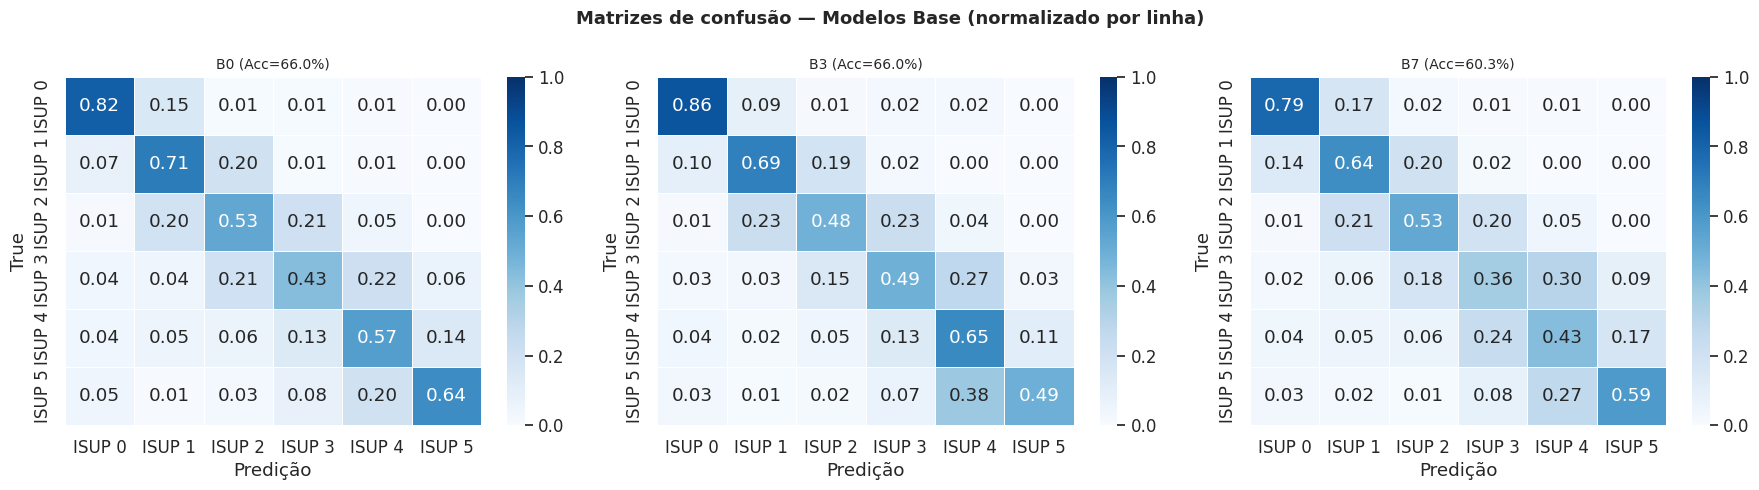

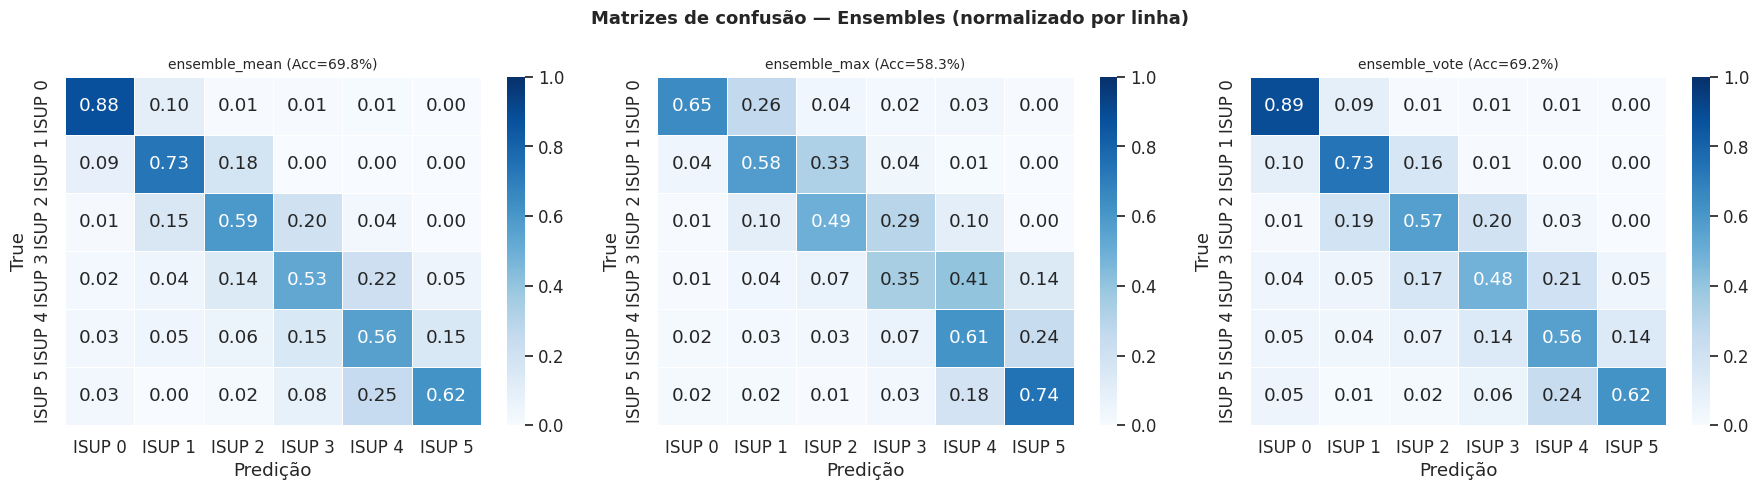

In [6]:
def plot_confusion_matrix(ax, y_true, y_pred, title, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        cm_plot = cm
        fmt = 'd'
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=ISUP_NAMES, yticklabels=ISUP_NAMES,
                linewidths=0.5, vmin=0, vmax=1 if normalize else None)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predição')
    ax.set_ylabel('True')

# --- Modelos base ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, MODELS):
    acc = metrics_df.loc[col, 'Accuracy']
    plot_confusion_matrix(ax, y, df[col], f'{col.upper()} (Acc={acc:.1f}%)')
fig.suptitle('Matrizes de confusão — Modelos Base (normalizado por linha)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Ensembles ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ENSEMBLES):
    acc = metrics_df.loc[col, 'Accuracy']
    plot_confusion_matrix(ax, y, df[col], f'{col} (Acc={acc:.1f}%)')
fig.suptitle('Matrizes de confusão — Ensembles (normalizado por linha)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 · Acurácia por classe ISUP

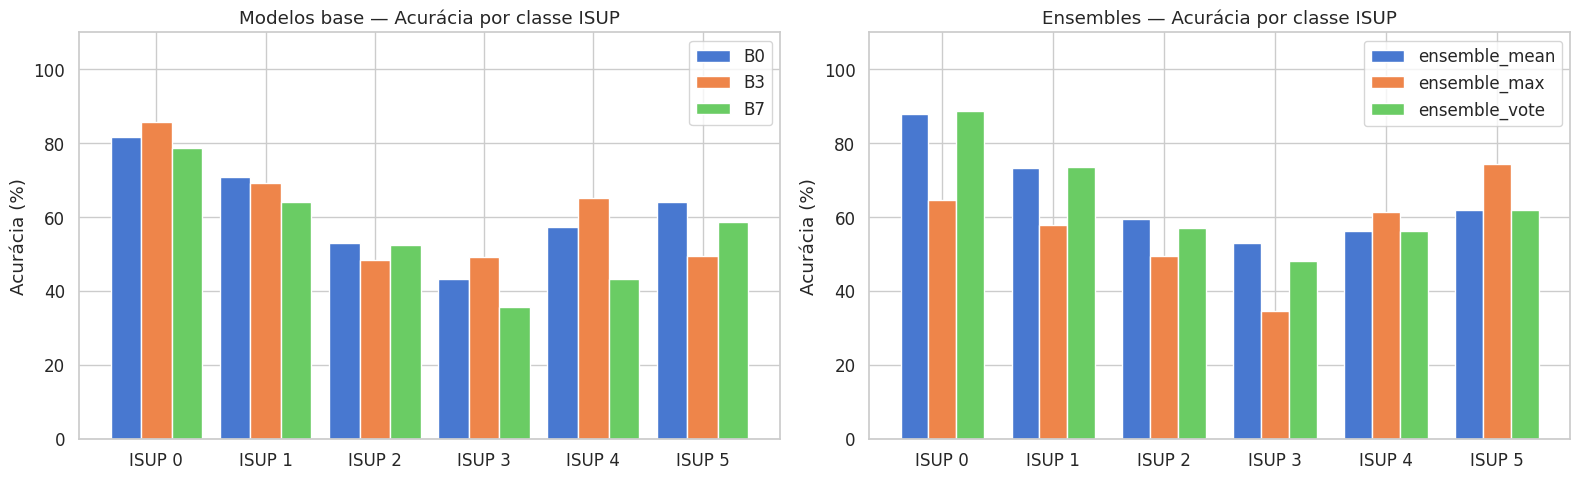


Acurácia por classe ISUP (%):


,b0,b3,b7,ensemble_mean,ensemble_max,ensemble_vote
ISUP,,,,,,
0,81.8,85.7,78.8,87.8,64.5,88.7
1,70.8,69.2,64.0,73.2,58.0,73.5
2,53.0,48.5,52.5,59.5,49.5,57.0
3,43.2,49.2,35.7,53.0,34.6,48.1
4,57.2,65.2,43.3,56.1,61.5,56.1
5,64.1,49.5,58.7,62.0,74.5,62.0


In [7]:
acc_class = pd.DataFrame(index=range(6))
for col in ALL_PREDS:
    acc_class[col] = df.groupby('true_label')[f'correct_{col}'].mean() * 100
acc_class.index.name = 'ISUP'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Modelos base
ax = axes[0]
x = np.arange(6)
w = 0.28
for i, m in enumerate(MODELS):
    ax.bar(x + (i - 1)*w, acc_class[m], w, label=m.upper())
ax.set_xticks(x)
ax.set_xticklabels(ISUP_NAMES)
ax.set_ylabel('Acurácia (%)')
ax.set_ylim(0, 110)
ax.set_title('Modelos base — Acurácia por classe ISUP')
ax.legend()

# Ensembles
ax = axes[1]
w = 0.25
for i, e in enumerate(ENSEMBLES):
    ax.bar(x + (i - 1)*w, acc_class[e], w, label=e)
ax.set_xticks(x)
ax.set_xticklabels(ISUP_NAMES)
ax.set_ylabel('Acurácia (%)')
ax.set_ylim(0, 110)
ax.set_title('Ensembles — Acurácia por classe ISUP')
ax.legend()

plt.tight_layout()
plt.show()

print('\nAcurácia por classe ISUP (%):')
acc_class.round(1)

---
## 5 · Distribuição de erros absolutos

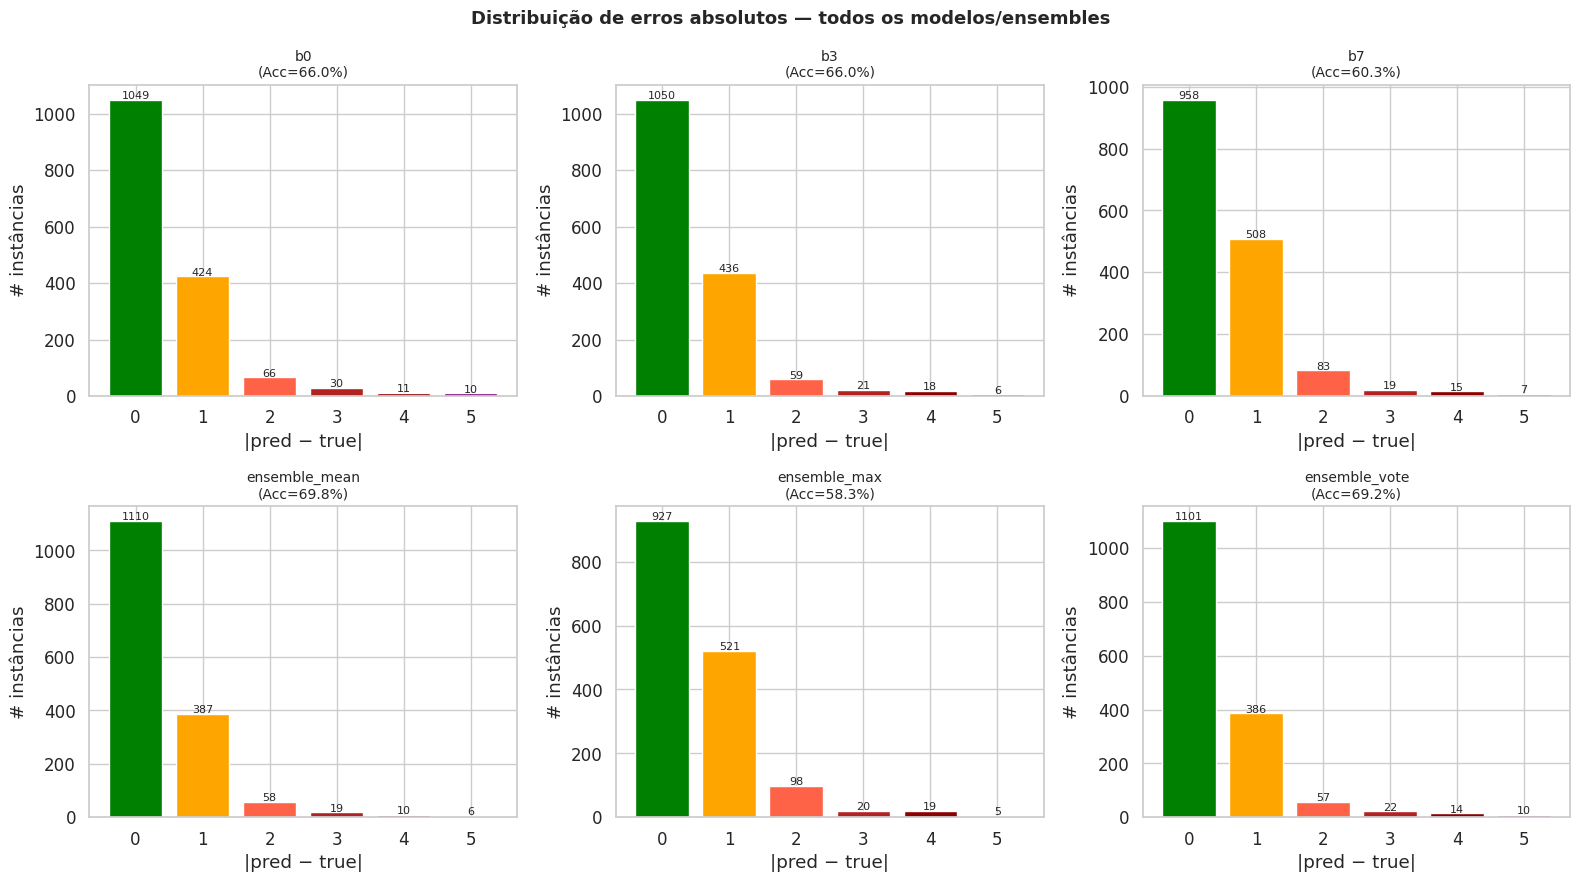

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
color_map = {0: 'green', 1: 'orange', 2: 'tomato', 3: 'firebrick',
             4: 'darkred', 5: 'purple'}

for ax, col in zip(axes.flatten(), ALL_PREDS):
    counts = df[f'err_{col}'].value_counts().sort_index()
    colors = [color_map.get(i, 'gray') for i in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    acc  = metrics_df.loc[col, 'Accuracy']
    ax.set_title(f'{col}\n(Acc={acc:.1f}%)', fontsize=10)
    ax.set_xlabel('|pred − true|')
    ax.set_ylabel('# instâncias')
    ax.set_xticks(counts.index)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(v), ha='center', fontsize=8)

fig.suptitle('Distribuição de erros absolutos — todos os modelos/ensembles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Análise das estratégias de ensemble

Comparação direta entre `ensemble_mean`, `ensemble_max` e `ensemble_vote`.

In [9]:
# Quando as três estratégias concordam vs. divergem
df['ens_unique'] = df[ENSEMBLES].nunique(axis=1)
print('Concordância entre estratégias de ensemble:')
print(df['ens_unique'].value_counts().rename({1: 'Todas concordam',
                                               2: '2 concordam',
                                               3: 'Todas divergem'}))
print()

# Quando concordam, qual a acurácia?
agree    = df[df['ens_unique'] == 1]
disagree = df[df['ens_unique'] > 1]
print(f'Quando todas concordam ({len(agree)} casos):')
for e in ENSEMBLES:
    print(f'  {e}: acc={agree[f"correct_{e}"].mean()*100:.1f}%')
print(f'Quando divergem ({len(disagree)} casos):')
for e in ENSEMBLES:
    print(f'  {e}: acc={disagree[f"correct_{e}"].mean()*100:.1f}%')

Concordância entre estratégias de ensemble:
ens_unique
Todas concordam    1087
2 concordam         426
Todas divergem       77
Name: count, dtype: int64

Quando todas concordam (1087 casos):
  ensemble_mean: acc=75.3%
  ensemble_max: acc=75.3%
  ensemble_vote: acc=75.3%
Quando divergem (503 casos):
  ensemble_mean: acc=58.1%
  ensemble_max: acc=21.7%
  ensemble_vote: acc=56.3%


In [10]:
# Para cada par de ensembles, quantos casos diferem?
pairs = [('ensemble_mean', 'ensemble_max'),
         ('ensemble_mean', 'ensemble_vote'),
         ('ensemble_max',  'ensemble_vote')]

print('Diferenças entre estratégias de ensemble:')
for a, b in pairs:
    diff = (df[a] != df[b]).sum()
    pct  = diff / len(df) * 100
    print(f'  {a} vs {b}: {diff} casos distintos ({pct:.1f}%)')
print()

# Casos onde mean acerta mas vote erra e vice-versa
mean_wins = df[df['correct_ensemble_mean'] & ~df['correct_ensemble_vote']]
vote_wins = df[~df['correct_ensemble_mean'] & df['correct_ensemble_vote']]
print(f'ensemble_mean certo, vote errado: {len(mean_wins)}')
print(f'ensemble_vote certo, mean errado: {len(vote_wins)}')

Diferenças entre estratégias de ensemble:
  ensemble_mean vs ensemble_max: 454 casos distintos (28.6%)
  ensemble_mean vs ensemble_vote: 192 casos distintos (12.1%)
  ensemble_max vs ensemble_vote: 437 casos distintos (27.5%)

ensemble_mean certo, vote errado: 74
ensemble_vote certo, mean errado: 65


In [11]:
# Ganho de cada ensemble sobre o melhor modelo base (B3)
best_base_col = metrics_df.loc[MODELS, 'Accuracy'].idxmax()
print(f'Melhor modelo base: {best_base_col} ({metrics_df.loc[best_base_col, "Accuracy"]:.2f}%)')
print()
for e in ENSEMBLES:
    gain = metrics_df.loc[e, 'Accuracy'] - metrics_df.loc[best_base_col, 'Accuracy']
    sign = '+' if gain >= 0 else ''
    print(f'  {e}: {metrics_df.loc[e, "Accuracy"]:.2f}%  (ganho: {sign}{gain:.2f}%)')

Melhor modelo base: b3 (66.04%)

  ensemble_mean: 69.81%  (ganho: +3.77%)
  ensemble_max: 58.30%  (ganho: -7.74%)
  ensemble_vote: 69.25%  (ganho: +3.21%)


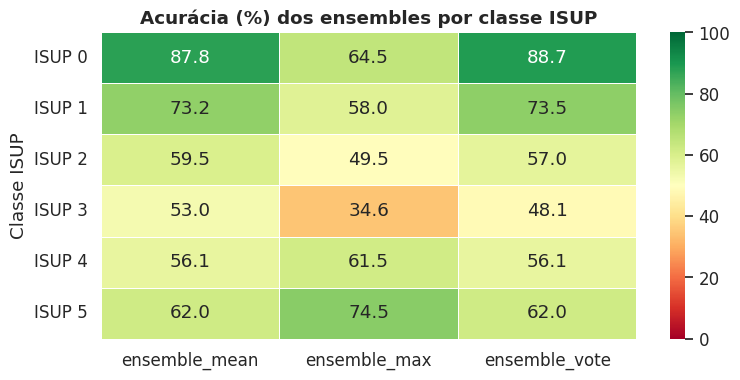

In [12]:
# Heatmap: acurácia de cada ensemble por classe ISUP
ens_acc = pd.DataFrame({
    e: df.groupby('true_label')[f'correct_{e}'].mean() * 100
    for e in ENSEMBLES
})
ens_acc.index = ISUP_NAMES

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(ens_acc, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, linewidths=0.5)
ax.set_title('Acurácia (%) dos ensembles por classe ISUP', fontweight='bold')
ax.set_ylabel('Classe ISUP')
plt.tight_layout()
plt.show()

---
## 7 · Consenso e divergência entre modelos base

In [13]:
all_correct = df[df['all_correct']]
all_wrong   = df[df['all_wrong']]

print(f'Consenso perfeito (todos certos) : {len(all_correct)} ({len(all_correct)/len(df)*100:.1f}%)')
print(f'Falha generalizada (todos errados): {len(all_wrong)} ({len(all_wrong)/len(df)*100:.1f}%)')
print()

# Acurácia dos ensembles nas duas situações extremas
print('Ensembles nos casos de consenso perfeito dos modelos base:')
for e in ENSEMBLES:
    print(f'  {e}: {all_correct[f"correct_{e}"].mean()*100:.1f}%')
print()
print('Ensembles nos casos de falha generalizada:')
for e in ENSEMBLES:
    print(f'  {e}: {all_wrong[f"correct_{e}"].mean()*100:.1f}%')

Consenso perfeito (todos certos) : 660 (41.5%)
Falha generalizada (todos errados): 271 (17.0%)

Ensembles nos casos de consenso perfeito dos modelos base:
  ensemble_mean: 100.0%
  ensemble_max: 100.0%
  ensemble_vote: 100.0%

Ensembles nos casos de falha generalizada:
  ensemble_mean: 3.3%
  ensemble_max: 0.0%
  ensemble_vote: 0.0%


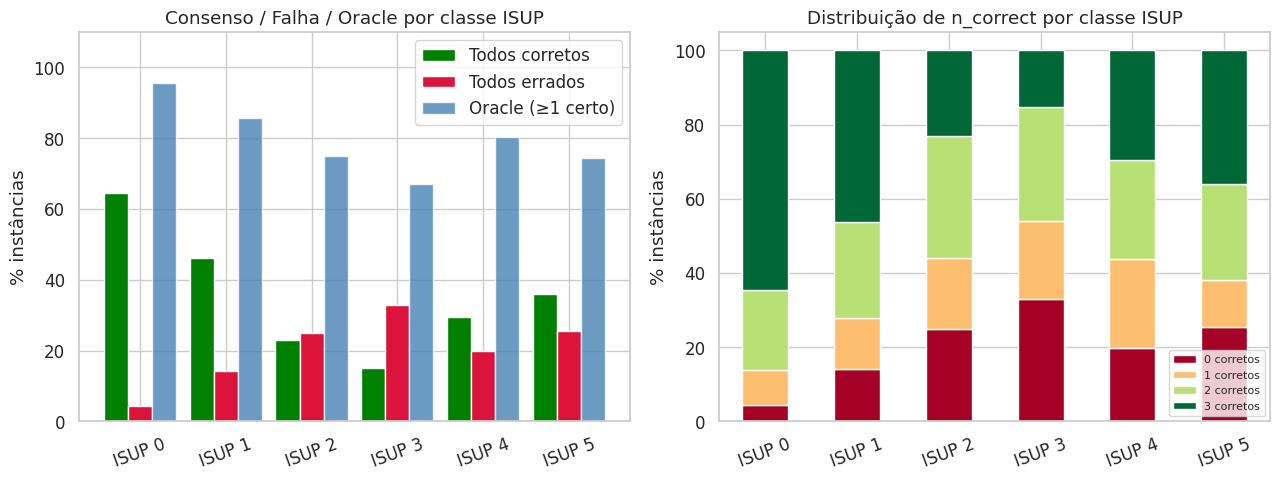

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(6)
w = 0.28

# Consenso correto por classe
ax = axes[0]
pct_correct = df.groupby('true_label')['all_correct'].mean() * 100
pct_wrong   = df.groupby('true_label')['all_wrong'].mean() * 100
pct_oracle  = df.groupby('true_label')['oracle_ok'].mean() * 100
ax.bar(x - w, pct_correct, w, label='Todos corretos', color='green')
ax.bar(x,     pct_wrong,   w, label='Todos errados',  color='crimson')
ax.bar(x + w, pct_oracle,  w, label='Oracle (≥1 certo)', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ISUP_NAMES, rotation=20)
ax.set_ylabel('% instâncias')
ax.set_title('Consenso / Falha / Oracle por classe ISUP')
ax.legend()
ax.set_ylim(0, 110)

# Distribuição de n_correct por classe
ax = axes[1]
pct_nc = df.groupby('true_label')['n_correct'].value_counts(normalize=True).unstack(fill_value=0) * 100
pct_nc.index = ISUP_NAMES
pct_nc.columns = [f'{c} corretos' for c in pct_nc.columns]
pct_nc.plot(kind='bar', ax=ax, stacked=True,
            colormap='RdYlGn', edgecolor='white')
ax.set_title('Distribuição de n_correct por classe ISUP')
ax.set_ylabel('% instâncias')
ax.set_xticklabels(ISUP_NAMES, rotation=20)
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# Desacordo total entre modelos base (3 predições distintas)
disagree3 = df[df['pred_unique'] == 3]
print(f'Desacordo total (3 preds distintas): {len(disagree3)} ({len(disagree3)/len(df)*100:.1f}%)')
print()

# Combinações mais frequentes
disagree3 = disagree3.copy()
disagree3['preds_tuple'] = disagree3.apply(
    lambda r: str(sorted([int(r['b0']), int(r['b3']), int(r['b7'])])), axis=1
)
print('Top 10 combinações de predições nos desacordos:')
print(disagree3['preds_tuple'].value_counts().head(10))
print()

# Acurácia dos ensembles nos casos de desacordo
print('Acurácia dos ensembles quando modelos base discordam totalmente:')
for e in ENSEMBLES:
    print(f'  {e}: {disagree3[f"correct_{e}"].mean()*100:.1f}%')

Desacordo total (3 preds distintas): 72 (4.5%)

Top 10 combinações de predições nos desacordos:
preds_tuple
[1, 2, 3]    17
[2, 3, 4]    16
[3, 4, 5]     9
[0, 1, 2]     8
[0, 1, 3]     4
[0, 3, 5]     4
[0, 1, 4]     2
[1, 3, 4]     2
[0, 3, 4]     2
[0, 4, 5]     2
Name: count, dtype: int64

Acurácia dos ensembles quando modelos base discordam totalmente:
  ensemble_mean: 38.9%
  ensemble_max: 22.2%
  ensemble_vote: 31.9%


---
## 8 · Erros graves — |pred − true| ≥ 3

In [16]:
print('Erros graves (|pred − true| ≥ 3) por modelo/ensemble:')
for col in ALL_PREDS:
    n   = (df[f'err_{col}'] >= 3).sum()
    pct = n / len(df) * 100
    print(f'  {col:25s}: {n:4d} ({pct:.1f}%)')
print()

serious = df[df['max_err'] >= 3]
print(f'Casos com ao menos 1 modelo base com erro ≥ 3: {len(serious)} ({len(serious)/len(df)*100:.1f}%)')

Erros graves (|pred − true| ≥ 3) por modelo/ensemble:
  b0                       :   51 (3.2%)
  b3                       :   45 (2.8%)
  b7                       :   41 (2.6%)
  ensemble_mean            :   35 (2.2%)
  ensemble_max             :   44 (2.8%)
  ensemble_vote            :   46 (2.9%)

Casos com ao menos 1 modelo base com erro ≥ 3: 81 (5.1%)


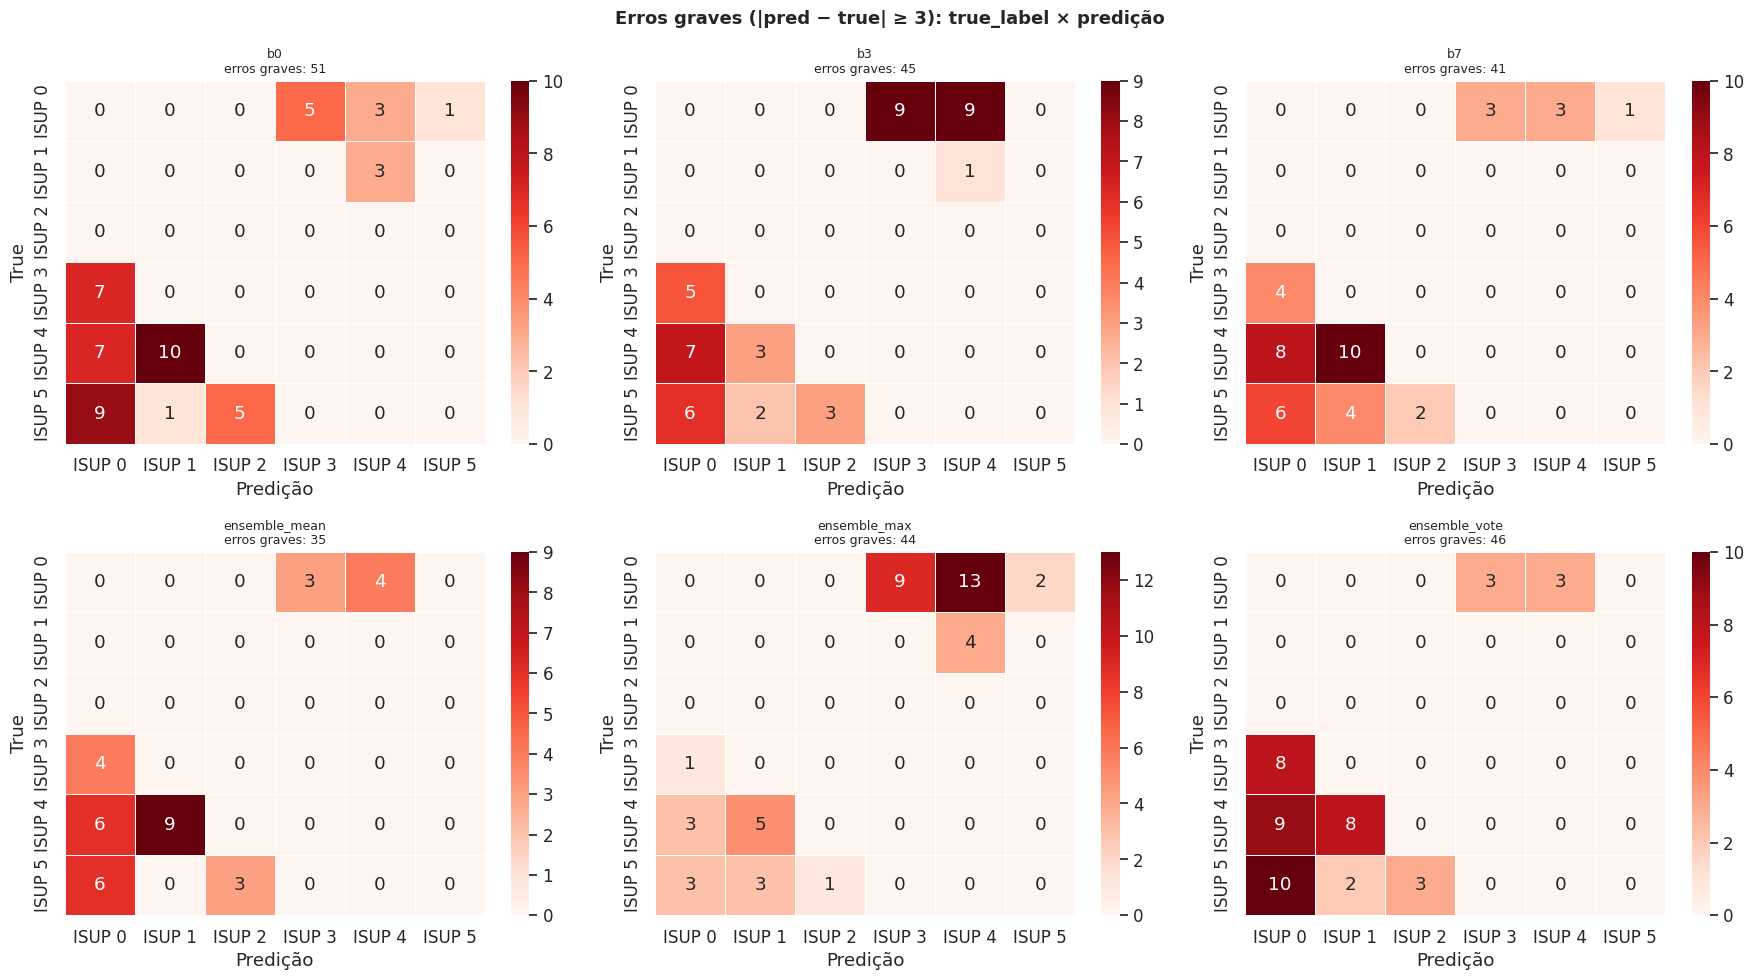

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ALL_PREDS):
    se = df[df[f'err_{col}'] >= 3]
    if len(se) == 0:
        ax.set_title(f'{col}\n(sem erros graves)')
        ax.axis('off')
        continue
    cross = pd.crosstab(se['true_label'], se[col])
    # Pad missing classes
    for cls in range(6):
        if cls not in cross.index:   cross.loc[cls] = 0
        if cls not in cross.columns: cross[cls]     = 0
    cross = cross.sort_index(axis=0).sort_index(axis=1)
    sns.heatmap(cross, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=[f'ISUP {c}' for c in cross.columns],
                yticklabels=[f'ISUP {i}' for i in cross.index],
                linewidths=0.5)
    n = (df[f'err_{col}'] >= 3).sum()
    ax.set_title(f'{col}\nerros graves: {n}', fontsize=9)
    ax.set_xlabel('Predição')
    ax.set_ylabel('True')

fig.suptitle('Erros graves (|pred − true| ≥ 3): true_label × predição',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9 · Erros adjacentes — |pred − true| = 1

In [18]:
print('Erros adjacentes (|pred − true| = 1) por modelo/ensemble:')
for col in ALL_PREDS:
    n   = (df[f'err_{col}'] == 1).sum()
    pct = n / len(df) * 100
    print(f'  {col:25s}: {n:4d} ({pct:.1f}%)')

print()
# Tendência de sub/superestimação
print('Viés dos modelos (positivo = tende a superestimar):')
for col in ALL_PREDS:
    bias = (df[col] - y).mean()
    print(f'  {col:25s}: {bias:+.4f}')

Erros adjacentes (|pred − true| = 1) por modelo/ensemble:
  b0                       :  424 (26.7%)
  b3                       :  436 (27.4%)
  b7                       :  508 (31.9%)
  ensemble_mean            :  387 (24.3%)
  ensemble_max             :  521 (32.8%)
  ensemble_vote            :  386 (24.3%)

Viés dos modelos (positivo = tende a superestimar):
  b0                       : -0.0176
  b3                       : -0.0069
  b7                       : -0.0239
  ensemble_mean            : -0.0314
  ensemble_max             : +0.3031
  ensemble_vote            : -0.0843


In [19]:
# Erros adjacentes por classe ISUP (todos os modelos base)
adj_b = df[(df['err_b0'] == 1) & (df['err_b3'] == 1) & (df['err_b7'] == 1)]
under = adj_b[(adj_b['b0'] < y) & (adj_b['b3'] < y) & (adj_b['b7'] < y)]
over  = adj_b[(adj_b['b0'] > y) & (adj_b['b3'] > y) & (adj_b['b7'] > y)]

print(f'Todos os modelos base com erro adjacente (=1): {len(adj_b)}')
print(f'  Todos subestimam (pred = true−1): {len(under)}')
print(f'  Todos superestimam (pred = true+1): {len(over)}')

ValueError: Can only compare identically-labeled Series objects

---
## 10 · Oracle upper-bound

In [20]:
oracle_ub    = df['oracle_ok'].mean() * 100
best_ens_acc = metrics_df.loc[ENSEMBLES, 'Accuracy'].max()
best_ens     = metrics_df.loc[ENSEMBLES, 'Accuracy'].idxmax()
best_base_acc = metrics_df.loc[MODELS, 'Accuracy'].max()

print(f'Oracle upper-bound (ao menos 1 modelo base certo): {oracle_ub:.2f}%')
print(f'Melhor modelo base ({best_base_col})            : {best_base_acc:.2f}%')
print(f'Melhor ensemble    ({best_ens})    : {best_ens_acc:.2f}%')
print()
print(f'Gap oracle − melhor ensemble : {oracle_ub - best_ens_acc:.2f}%')
print(f'Gap oracle − melhor base     : {oracle_ub - best_base_acc:.2f}%')
print()

# Oracle por classe ISUP
print('Oracle upper-bound por classe ISUP:')
oracle_by_class = df.groupby('true_label')['oracle_ok'].mean() * 100
oracle_by_class.index = ISUP_NAMES
print(oracle_by_class.round(1))

Oracle upper-bound (ao menos 1 modelo base certo): 82.96%
Melhor modelo base (b3)            : 66.04%
Melhor ensemble    (ensemble_mean)    : 69.81%

Gap oracle − melhor ensemble : 13.14%
Gap oracle − melhor base     : 16.92%

Oracle upper-bound por classe ISUP:
ISUP 0    95.6
ISUP 1    85.8
ISUP 2    75.0
ISUP 3    67.0
ISUP 4    80.2
ISUP 5    74.5
Name: oracle_ok, dtype: float64


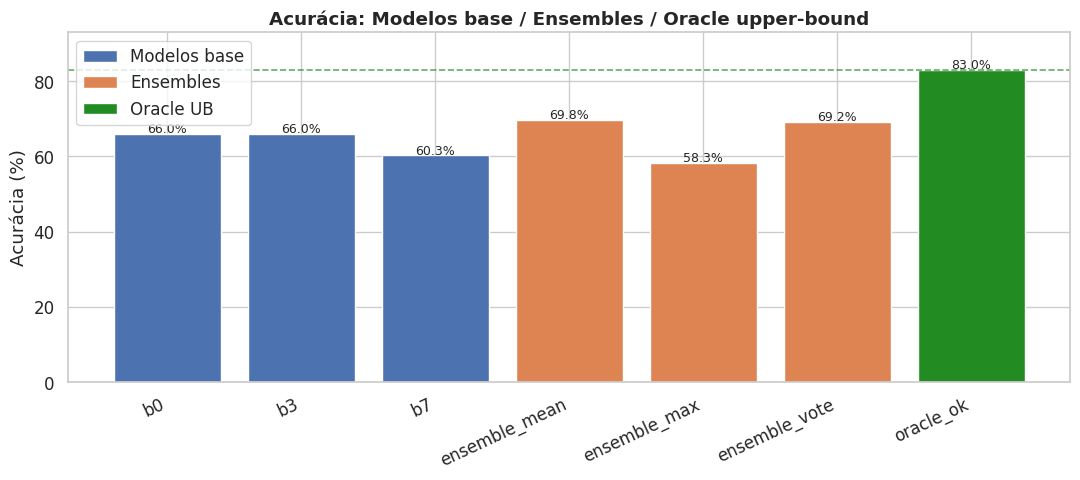

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))

cols_to_plot = ALL_PREDS + ['oracle_ok']
accs = [metrics_df.loc[c, 'Accuracy'] if c != 'oracle_ok' else oracle_ub
        for c in cols_to_plot]
labels = cols_to_plot
colors = (['#4C72B0'] * 3 + ['#DD8452'] * 3 + ['forestgreen'])

bars = ax.bar(labels, accs, color=colors, edgecolor='white')
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', fontsize=9)

ax.set_ylabel('Acurácia (%)')
ax.set_title('Acurácia: Modelos base / Ensembles / Oracle upper-bound', fontweight='bold')
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylim(0, oracle_ub + 10)
ax.axhline(oracle_ub, color='forestgreen', linestyle='--', linewidth=1.2, alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Modelos base'),
                   Patch(facecolor='#DD8452', label='Ensembles'),
                   Patch(facecolor='forestgreen', label='Oracle UB')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

---
## 11 · Casos mais difíceis

In [26]:
# Top 15 casos com maior desvio-padrão entre predições dos modelos base
hardest = df.nlargest(50, 'pred_std')
display_cols = ['img_id', 'true_label'] + ALL_PREDS + ['pred_std', 'n_correct']
print('Top 15 casos com maior discordância entre modelos base (pred_std):')
hardest[display_cols].to_string(index=False)

Top 15 casos com maior discordância entre modelos base (pred_std):


'                          img_id  true_label  b0  b3  b7  ensemble_mean  ensemble_max  ensemble_vote  pred_std  n_correct\n11edd2e754f196b7655508e0e3177fdf           4   0   5   4              1             5              0  2.645751          1\ne13ad43ca93b81c3461ec29c1ca41106           3   0   5   4              4             5              0  2.645751          0\n105cbd187035503e56605db53600b491           5   0   3   5              3             5              0  2.516611          1\n39026a5b4f7486acd7ab9d02482ff69b           0   3   0   5              3             5              0  2.516611          1\n39f36065811dabb953b5fa41f826f669           5   5   3   0              3             5              0  2.516611          1\na65bd71b4d413c0d11b8e39e792c11ea           5   0   5   3              3             5              0  2.516611          1\n05812e40387f49e4b21a7bfeca0cca2d           3   0   4   0              1             4              0  2.309401          0\n102aaf6f71973e1

In [27]:
hardest[display_cols].style \
    .background_gradient(cmap='Reds', subset=['pred_std']) \
    .background_gradient(cmap='RdYlGn', subset=['n_correct'])

,img_id,true_label,b0,b3,b7,ensemble_mean,ensemble_max,ensemble_vote,pred_std,n_correct
1104,11edd2e754f196b7655508e0e3177fdf,4,0,5,4,1,5,0,2.645751,1
1196,e13ad43ca93b81c3461ec29c1ca41106,3,0,5,4,4,5,0,2.645751,0
369,105cbd187035503e56605db53600b491,5,0,3,5,3,5,0,2.516611,1
785,39026a5b4f7486acd7ab9d02482ff69b,0,3,0,5,3,5,0,2.516611,1
1030,39f36065811dabb953b5fa41f826f669,5,5,3,0,3,5,0,2.516611,1
1282,a65bd71b4d413c0d11b8e39e792c11ea,5,0,5,3,3,5,0,2.516611,1
15,05812e40387f49e4b21a7bfeca0cca2d,3,0,4,0,1,4,0,2.309401,0
91,102aaf6f71973e1fe82551918255ba58,1,4,0,0,0,4,0,2.309401,0
188,b1592124fa872ab5ad10d0d5dbf80a30,0,4,0,4,4,4,4,2.309401,1
207,d6f1c51db42f3d11c7001141d7b417a7,0,0,4,0,0,4,0,2.309401,2


In [24]:
# Casos com gap máximo ≥ 4 entre modelos base
extreme = df[df['max_gap'] >= 4].sort_values('max_gap', ascending=False)
print(f'Casos com gap máximo entre predições (base) ≥ 4: {len(extreme)}')
extreme[display_cols].head(10)

Casos com gap máximo entre predições (base) ≥ 4: 25


,img_id,true_label,b0,b3,b7,ensemble_mean,ensemble_max,ensemble_vote,pred_std,n_correct
369,105cbd187035503e56605db53600b491,5,0,3,5,3,5,0,2.516611,1
785,39026a5b4f7486acd7ab9d02482ff69b,0,3,0,5,3,5,0,2.516611,1
1282,a65bd71b4d413c0d11b8e39e792c11ea,5,0,5,3,3,5,0,2.516611,1
1104,11edd2e754f196b7655508e0e3177fdf,4,0,5,4,1,5,0,2.645751,1
1030,39f36065811dabb953b5fa41f826f669,5,5,3,0,3,5,0,2.516611,1
1196,e13ad43ca93b81c3461ec29c1ca41106,3,0,5,4,4,5,0,2.645751,0
15,05812e40387f49e4b21a7bfeca0cca2d,3,0,4,0,1,4,0,2.309401,0
188,b1592124fa872ab5ad10d0d5dbf80a30,0,4,0,4,4,4,4,2.309401,1
91,102aaf6f71973e1fe82551918255ba58,1,4,0,0,0,4,0,2.309401,0
502,111b51550e629492736d9a6f26c21456,5,4,4,0,4,4,4,2.309401,0


---
## 12 · Sumário final

In [25]:
line = '=' * 65
print(line)
print('SUMÁRIO — oracle_2.csv')
print(line)
print(f'Total de instâncias : {len(df)}')
print(f'Classes ISUP        : {sorted(y.unique())}')
print()
print(f'{"Modelo/Ensemble":<25} {"Acc (%)":>8} {"MAE":>8} {"QWK":>8} {"Erros≥3":>9}')
print('-' * 65)
for col in ALL_PREDS:
    acc   = metrics_df.loc[col, 'Accuracy']
    mae   = metrics_df.loc[col, 'MAE']
    qwk   = metrics_df.loc[col, 'QWK']
    se    = (df[f'err_{col}'] >= 3).sum()
    print(f'{col:<25} {acc:>8.2f} {mae:>8.4f} {qwk:>8.4f} {se:>9}')
print()
print(f'Consenso perfeito (todos base certos) : {df["all_correct"].sum():4d} ({df["all_correct"].mean()*100:.1f}%)')
print(f'Falha generalizada (todos base erram) : {df["all_wrong"].sum():4d} ({df["all_wrong"].mean()*100:.1f}%)')
print(f'Oracle upper-bound (≥1 base certo)   : {df["oracle_ok"].sum():4d} ({oracle_ub:.1f}%)')
print(f'Desacordo total (3 preds distintas)  : {(df["pred_unique"]==3).sum():4d} ({(df["pred_unique"]==3).mean()*100:.1f}%)')
print(f'Gap extremo entre bases (≥4)         : {len(extreme):4d}')
print(line)

SUMÁRIO — oracle_2.csv
Total de instâncias : 1590
Classes ISUP        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Modelo/Ensemble            Acc (%)      MAE      QWK   Erros≥3
-----------------------------------------------------------------
b0                           65.97   0.4654   0.8484        51
b3                           66.04   0.4522   0.8570        45
b7                           60.25   0.5195   0.8440        41
ensemble_mean                69.81   0.3962   0.8800        35
ensemble_max                 58.30   0.5522   0.8396        44
ensemble_vote                69.25   0.4226   0.8598        46

Consenso perfeito (todos base certos) :  660 (41.5%)
Falha generalizada (todos base erram) :  271 (17.0%)
Oracle upper-bound (≥1 base certo)   : 1319 (83.0%)
Desacordo total (3 preds distintas)  :   72 (4.5%)
Gap extremo entre bases (≥4)         :   25


In [29]:
cond_ensemble_acertou = df['ensemble_mean'] == df['true_label']
cond_divergencia_total = df[['b0', 'b3', 'b7']].nunique(axis=1) == 3

casos_sucesso_ensemble_extremo = df[cond_divergencia_total & cond_ensemble_acertou]

print('Casos onde os modelos base divergiram, mas o ensemble acertou:')

casos_sucesso_ensemble_extremo[display_cols].style \
    .background_gradient(cmap='Reds', subset=['pred_std']) \
    .background_gradient(cmap='RdYlGn', subset=['n_correct'])

Casos onde os modelos base divergiram, mas o ensemble acertou:


,img_id,true_label,b0,b3,b7,ensemble_mean,ensemble_max,ensemble_vote,pred_std,n_correct
6,20c05ea5426b6c50b857057ad0ef7126,2,1,3,2,2,3,1,1.000000,1
8,3202735e79f54cef6981c1b481f18859,1,2,1,0,1,2,0,1.000000,1
79,5667bcf82d6fee7017e4435ba066e1f7,2,3,2,1,2,3,1,1.000000,1
101,9f7ee4a75044aace7725bf008d651003,3,4,3,2,3,4,2,1.000000,1
142,8fcc3efc049396629dedaf22cb4a1c14,3,3,2,4,3,4,2,1.000000,1
216,0d7666fdc3372c68a080c612081e2b45,0,1,0,2,0,2,0,1.000000,1
377,d844c98b020831cd13e0dbed2f72e719,1,1,3,2,1,3,1,1.000000,1
525,0abc61a1bc7abe47b9e44a9f69979eb0,2,3,2,1,2,3,1,1.000000,1
623,d887469d2d1a490b480e32c145c68469,1,0,1,2,1,2,0,1.000000,1
647,145ae6f948b36cb450a7eeb9cbac4cfa,5,5,4,3,5,5,3,1.000000,1


In [32]:
acertos_ensemble = df[df['ensemble_mean'] == df['true_label']]

# 2. Conta quando SOMENTE b0 acertou (b0 == true_label, e os outros != true_label)
acertos_so_b0 = ((acertos_ensemble['b0'] == acertos_ensemble['true_label']) &
                 (acertos_ensemble['b3'] != acertos_ensemble['true_label']) &
                 (acertos_ensemble['b7'] != acertos_ensemble['true_label'])).sum()

# 3. Conta quando SOMENTE b3 acertou
acertos_so_b3 = ((acertos_ensemble['b0'] != acertos_ensemble['true_label']) &
                 (acertos_ensemble['b3'] == acertos_ensemble['true_label']) &
                 (acertos_ensemble['b7'] != acertos_ensemble['true_label'])).sum()

# 4. Conta quando SOMENTE b7 acertou
acertos_so_b7 = ((acertos_ensemble['b0'] != acertos_ensemble['true_label']) &
                 (acertos_ensemble['b3'] != acertos_ensemble['true_label']) &
                 (acertos_ensemble['b7'] == acertos_ensemble['true_label'])).sum()

# Mostra os resultados
print(f"O ensemble acertou puxado apenas pelo b0: {acertos_so_b0} vezes")
print(f"O ensemble acertou puxado apenas pelo b3: {acertos_so_b3} vezes")
print(f"O ensemble acertou puxado apenas pelo b7: {acertos_so_b7} vezes")

O ensemble acertou puxado apenas pelo b0: 30 vezes
O ensemble acertou puxado apenas pelo b3: 25 vezes
O ensemble acertou puxado apenas pelo b7: 15 vezes


In [39]:
erros_ensemble = df[df['ensemble_mean'] != df['true_label']]

erros = ((erros_ensemble['b0'] == erros_ensemble['true_label']) |
                 (erros_ensemble['b3'] == erros_ensemble['true_label']) |
                 (erros_ensemble['b7'] == erros_ensemble['true_label']))

print(f"O ensemble erros: {erros.sum()} vezes")

O ensemble erros: 218 vezes
